## Basic Feature Engineering Pipeline

### By:
Gabriel Múnera González

### Date:
2026-08-21

### Description:

Create a feature engineering pipeline based on the conclusions and recommendations of the manual EDA notebook `notebooks/3-analysis/02-jrz-data_description_Manual-pandas-2024_10_24.ipynb`.

The feature engineering will be performed using scikit-learn pipelines and transformers, and will:

- Drop exact duplicate rows and the handful of data-entry-corrupted rows identified in the EDA.
- Engineer a `volume = x * y * z` feature and use it (together with `carat`) instead of the raw, near-collinear `x`/`y`/`z` columns.
- Encode `cut`, `color` and `clarity` as **ordinal** features (not one-hot), since the EDA showed all three are ordered quality grades with a monotonic effect on `price`.
- Use a `clarity` × `cut` **stratified** train/test split, since the EDA found some grade combinations (e.g. `IF` clarity, `Fair` cut) are rare and a purely random split could under-represent them.

## 📚 Import  libraries

In [27]:
# base libraries for data science
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import seaborn as sns
import sklearn as sk
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OrdinalEncoder, StandardScaler

## 💾 Load data

In [8]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"

diamantes_df = pd.read_parquet(
    DATA_DIR / "02_intermediate/diamantes_type_fixed.parquet", engine="pyarrow"
)
diamantes_df.shape

(19231, 10)

In [9]:
# print library version for reproducibility

print("Pandas version: ", pd.__version__)
print("Numpy version: ", np.__version__)
print("sklearn version: ", sk.__version__)

Pandas version:  2.3.3
Numpy version:  2.3.5
sklearn version:  1.9.0


## 👷 Data preparation

Handle duplicated rows, missing values and outliers before building the encoding pipeline.

No column is dropped outright — every raw column either carries direct signal (`carat`, `cut`, `color`, `clarity`) or feeds into an engineered feature (`x`, `y`, `z` → `volume`; `depth`, `table` stay as cut-proportion features). The one explicit exception, per the EDA conclusions, is `price_per_carat`: it is a diagnostic ratio computed *from* the target `price` and must never be used as a model input, since it would leak the target. It is not created in this notebook at all.

### Missing values

In [10]:
diamantes_df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

No missing values are present in the raw data (confirmed here and in the EDA notebook). `SimpleImputer` is still included in every pipeline branch below as a defensive step, so the same pipeline stays valid if future or production data does contain gaps.

### Duplicated data

In [11]:
duplicate_rows = diamantes_df.duplicated().sum()
print("Number of duplicate rows: ", duplicate_rows)

diamantes_dedup_df = diamantes_df.drop_duplicates().reset_index(drop=True)
print("Shape before dedup: ", diamantes_df.shape)
print("Shape after dedup:  ", diamantes_dedup_df.shape)

Number of duplicate rows:  250
Shape before dedup:  (19231, 10)
Shape after dedup:   (18981, 10)


250 rows (1.3%) are exact duplicates across all 10 columns — the same `carat`/`cut`/`color`/`clarity`/`depth`/`table`/`x`/`y`/`z` **and** the same `price` down to the last cell. This is plausible in a catalog-style dataset where many stones share identical rounded specs and a formula-driven list price, but keeping them would let the same record leak across the train/test split (once it's duplicated, part of it can land in train and part in test) and would silently up-weight whichever spec combination happens to repeat. They are dropped here, before the split.

### Outliers removal

The EDA notebook found two independent signs of genuine, non-statistical data-entry errors — records where a value was copy-pasted from the wrong column — and confirmed that everything else in the size/proportion columns, however extreme it looks in a boxplot, is real. This section reproduces both checks, removes only what is actually broken, and explains why the rest is kept.

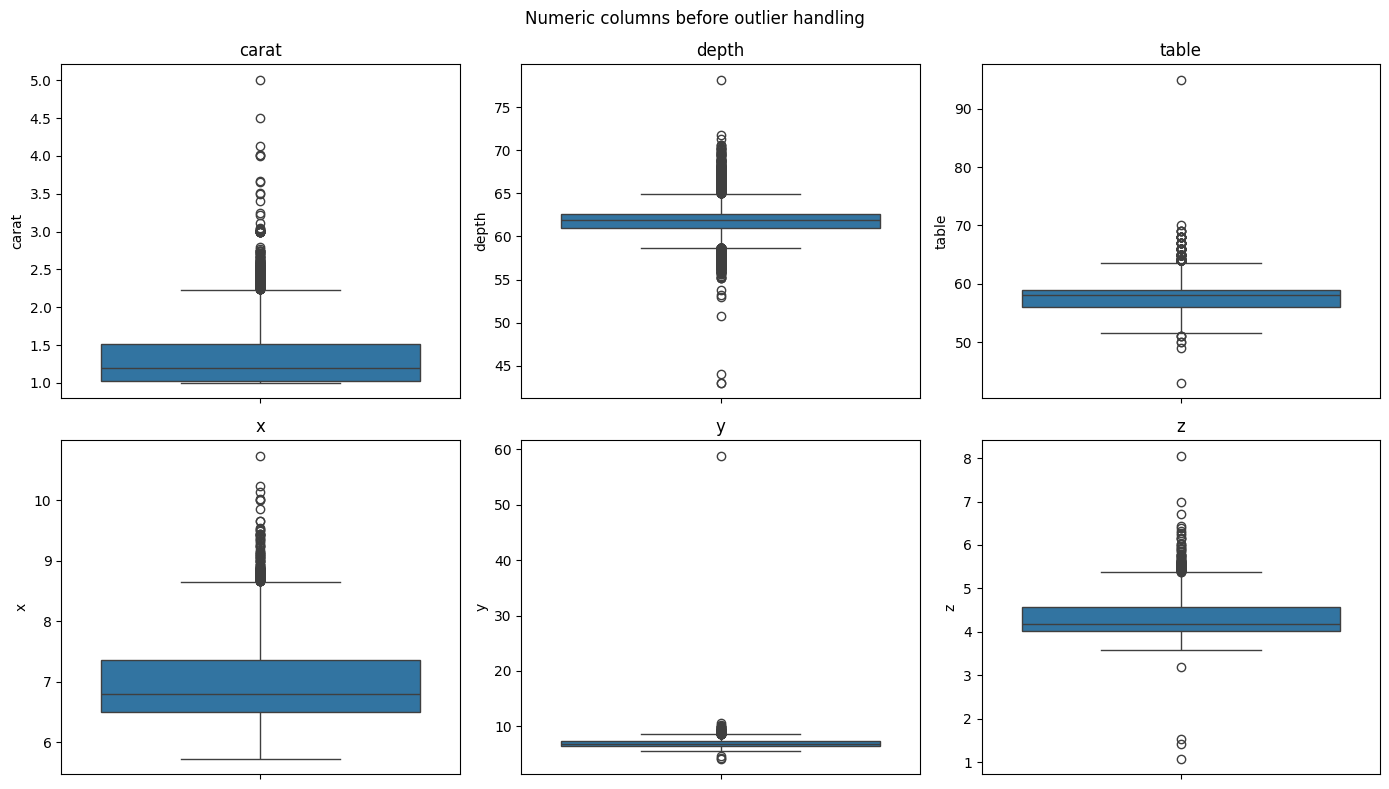

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), ["carat", "depth", "table", "x", "y", "z"], strict=True):
    sns.boxplot(y=diamantes_dedup_df[col], ax=ax)
    ax.set_title(col)
plt.suptitle("Numeric columns before outlier handling")
plt.tight_layout()
plt.show()

#### Data-entry errors (genuine, physically impossible values)

Two cross-column consistency checks — a stone's `z` (height) can't equal its `carat` (weight) by coincidence, and its `y` (width) can't equal its `depth` (a ~60 proportion) — flagged 4 rows in the EDA as column-swap errors:

In [13]:
mask_corrupt = (diamantes_dedup_df["z"] == diamantes_dedup_df["carat"]) | (
    diamantes_dedup_df["y"] == diamantes_dedup_df["depth"]
)
print(f"Corrupted rows: {mask_corrupt.sum()}")
diamantes_dedup_df.loc[mask_corrupt]

Corrupted rows: 4


,carat,cut,color,clarity,depth,table,price,x,y,z
7200,1.07,Ideal,F,SI1,60.599998,57.0,5909,6.62,6.670000,1.07
12590,1.53,Ideal,I,SI1,61.900002,54.0,8971,7.43,7.500000,1.53
13456,1.41,Ideal,H,VS1,60.700001,56.0,9752,7.31,7.220000,1.41
15590,2.00,Premium,H,SI2,58.900002,57.0,12210,8.09,58.900002,8.06


These 4 rows can't be corrected (we don't know the true value that got overwritten), so they are dropped rather than imputed.

In [14]:
diamantes_clean_df = diamantes_dedup_df.loc[~mask_corrupt].reset_index(drop=True)
print("Shape before:", diamantes_dedup_df.shape)
print("Shape after: ", diamantes_clean_df.shape)

Shape before: (18981, 10)
Shape after:  (18977, 10)


#### Statistical outliers: checked, mostly kept

A standard Tukey fence (values beyond `Q1 - 3×IQR` / `Q3 + 3×IQR`, the conservative "extreme outlier" threshold — a tighter 1.5×IQR fence would flag over 2% of `carat` alone, which is just its normal right skew) flags a small number of additional points on every numeric column. Before removing any of them, it's worth checking *why* they're extreme:

In [ ]:
iqr_bounds = {}
for col in ["carat", "depth", "table", "x", "y", "z"]:
    q1, q3 = diamantes_clean_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 3 * iqr, q3 + 3 * iqr
    iqr_bounds[col] = (lo, hi)
    n_out = ((diamantes_clean_df[col] < lo) | (diamantes_clean_df[col] > hi)).sum()
    print(
        f"{col:8s} bounds=({lo:.2f}, {hi:.2f})  extreme outliers={n_out} ({n_out / len(diamantes_clean_df):.2%})"
    )

print()
depth_lo, depth_hi = iqr_bounds["depth"]
depth_extreme = diamantes_clean_df[
    (diamantes_clean_df["depth"] < depth_lo) | (diamantes_clean_df["depth"] > depth_hi)
]
print(f"cut distribution among the {len(depth_extreme)} depth outliers:")
depth_extreme["cut"].value_counts()

carat    bounds=(-0.41, 2.95)  extreme outliers=38 (0.20%)
depth    bounds=(56.20, 67.40)  extreme outliers=117 (0.62%)
table    bounds=(47.00, 68.00)  extreme outliers=7 (0.04%)
x        bounds=(3.92, 9.94)  extreme outliers=6 (0.03%)
y        bounds=(3.92, 9.94)  extreme outliers=3 (0.02%)
z        bounds=(2.40, 6.18)  extreme outliers=7 (0.04%)

cut distribution among the 117 depth outliers:


cut
Fair         115
Good           1
Ideal          1
Premium        0
Very Good      0
Name: count, dtype: int64

`carat` alone would lose 38 rows (0.2%) to the 3×IQR fence — and every one of them is simply a large, expensive, genuinely-sold diamond; removing them would bias the model away from exactly the high-value stones it should learn to price. `depth` flags 117 rows (0.6%), and **98% of those (115/117) are `Fair`-cut diamonds** — an unusually shallow or deep proportion is *the reason* a stone is graded `Fair`, not a measurement error, so dropping them would erase the physical signature that makes `cut` predictive in the first place. The single `table ≈ 95` row (vs. a typical ~55–65) is the most extreme individual value in the dataset, but its price is still within the heuristic model's normal error range for its carat/clarity/color/cut combination (from the EDA notebook), so it's kept as a legitimate, if unusually cut, stone rather than assumed to be an error.

**Outlier handling summary**: only the 4 cross-column-corrupted rows are removed. Statistically extreme but physically consistent values are kept, since — per the EDA — they carry real pricing signal (`carat`'s right skew, `Fair`-cut proportions) rather than noise.

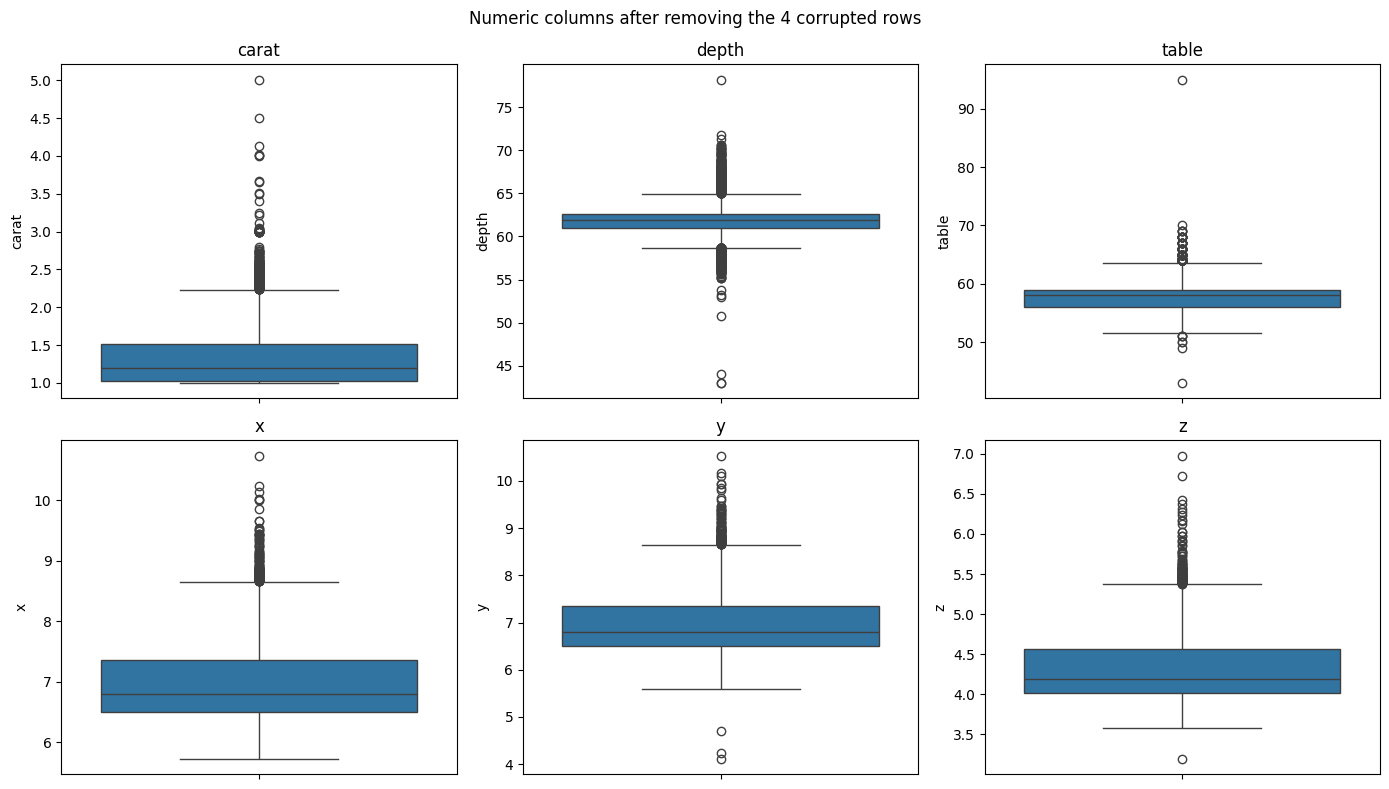

Final shape: (18977, 10) (dropped 254 rows total: 250 duplicates + 4 corrupted)


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), ["carat", "depth", "table", "x", "y", "z"], strict=True):
    sns.boxplot(y=diamantes_clean_df[col], ax=ax)
    ax.set_title(col)
plt.suptitle("Numeric columns after removing the 4 corrupted rows")
plt.tight_layout()
plt.show()

print(
    f"Final shape: {diamantes_clean_df.shape} (dropped {len(diamantes_df) - len(diamantes_clean_df)} "
    f"rows total: {duplicate_rows} duplicates + {mask_corrupt.sum()} corrupted)"
)

## 👨‍🏭 Feature Engineering

1. **Numeric Pipeline**:
   - **Columns**: `["carat", "depth", "table"]`
   - **Steps**:
     - `SimpleImputer(strategy="median")`: robust to `price`/`carat`'s right skew.
     - `StandardScaler()`: harmless for the tree-based estimator recommended in the EDA, and needed if a linear/distance-based model is tried instead.

2. **Volume Pipeline** *(engineered feature, replaces `x`, `y`, `z`)*:
   - **Columns**: `["x", "y", "z"]`
   - **Steps**:
     - `SimpleImputer(strategy="median")`
     - `FunctionTransformer(compute_volume)`: reduces the 3 raw dimensions to a single `volume = x * y * z` feature.
     - `StandardScaler()`
   - The EDA found `carat`, `x`, `y`, `z` and `volume` are all near-duplicate size measures (pairwise r up to 0.98, `carat`↔`volume` r ≈ 0.92). Keeping `carat` **and** `volume` — instead of `carat` **and** `x`/`y`/`z` — keeps almost all of that size information in 2 features instead of 4, cutting the worst of the multicollinearity while still letting a tree model split on fine-grained shape imbalances that `carat` alone wouldn't show.

3. **Categorical Ordinal Pipeline** *(no nominal/one-hot columns — every diamond category is an ordered grade)*:
   - **Columns**: `["cut", "color", "clarity"]`
   - **Steps**:
     - `SimpleImputer(strategy="most_frequent")`
     - `OrdinalEncoder(categories=[...])` with the grade order fixed explicitly (worst → best) for each column, matching the monotonic `price` relationship the EDA found for all three grades — `color` is encoded `J → D` (not alphabetically `D → J`) so that a higher code means a higher expected price premium, consistent with `cut` and `clarity`.

4. **Column Transformer**:
   - Combines the numeric, volume and categorical-ordinal pipelines into a single preprocessing step, operating directly on the raw `carat`/`depth`/`table`/`x`/`y`/`z`/`cut`/`color`/`clarity` columns (so it can be reused as-is at inference time on new, un-engineered rows).

In [17]:
numeric_features = ["carat", "depth", "table"]
volume_source_features = ["x", "y", "z"]
categorical_ordinal_features = ["cut", "color", "clarity"]

# Grade order fixed explicitly, worst -> best, matching the monotonic price
# effect found in the EDA (so a higher ordinal code means a higher expected price).
ordinal_categories = {
    "cut": ["Fair", "Good", "Very Good", "Premium", "Ideal"],
    "color": ["J", "I", "H", "G", "F", "E", "D"],
    "clarity": ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"],
}

In [ ]:
def compute_volume(X: np.ndarray) -> np.ndarray:
    """Collapse the x, y, z dimensions into a single volume = x * y * z column."""
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    return (x * y * z).reshape(-1, 1)


volume_transformer = FunctionTransformer(
    compute_volume,
    feature_names_out=lambda transformer, input_features: np.array(["volume"]),
)

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

volume_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("volume", volume_transformer),
        ("scaler", StandardScaler()),
    ]
)

categorical_ordinal_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "ordinal",
            OrdinalEncoder(
                categories=[ordinal_categories[col] for col in categorical_ordinal_features]
            ),
        ),
    ]
)

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("volume", volume_pipeline, volume_source_features),
        ("cat_ordinal", categorical_ordinal_pipeline, categorical_ordinal_features),
    ]
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('volume', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featur

## Example of the data preprocessing pipeline


### Train / Test split

`price` is continuous, so it can't be the `stratify` key directly — but the EDA's Proposals section is explicit: *"use the carat×clarity interaction found here to justify a stratified train/test split ... by clarity and cut, since some combinations (e.g. IF clarity, Fair cut) are rare and a random split could under-represent them."* Some `clarity`×`cut` combinations are indeed very small (`VVS1`+`Fair` has only 4 rows in the whole dataset, `IF`+`Fair` has 0), so we build a single combined `clarity_cut` key and stratify the split on it — this keeps the proportion of every grade combination identical in train and test, instead of leaving the rarest ones to chance.

In [ ]:
feature_columns = numeric_features + volume_source_features + categorical_ordinal_features
target_column = "price"

X = diamantes_clean_df[feature_columns]
y = diamantes_clean_df[target_column]

# combined ordinal-grade key used only for stratification, never as a model feature
clarity_cut_key = (
    diamantes_clean_df["clarity"].astype(str) + "_" + diamantes_clean_df["cut"].astype(str)
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=clarity_cut_key
)

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")

X_train: (15181, 9)  X_test: (3796, 9)


In [ ]:
# sanity check: clarity x cut proportions should match closely between train and test
clarity_cut_props = pd.DataFrame(
    {
        "train": X_train["clarity"]
        .astype(str)
        .str.cat(X_train["cut"].astype(str), sep="_")
        .value_counts(normalize=True),
        "test": X_test["clarity"]
        .astype(str)
        .str.cat(X_test["cut"].astype(str), sep="_")
        .value_counts(normalize=True),
    }
)
clarity_cut_props["abs_diff_pp"] = (
    (clarity_cut_props["train"] - clarity_cut_props["test"]) * 100
).abs()
clarity_cut_props.sort_values("abs_diff_pp", ascending=False).head(10)

,train,test,abs_diff_pp
clarity,,,
VS2_Premium,0.071734,0.071918,0.018340
SI1_Premium,0.084909,0.085090,0.018080
VS1_Very Good,0.026480,0.026344,0.013695
VS1_Good,0.010671,0.010537,0.013383
SI1_Fair,0.010408,0.010274,0.013377
I1_Ideal,0.006192,0.006059,0.013294
VVS2_Fair,0.000922,0.000790,0.013190
IF_Premium,0.003030,0.003161,0.013112
I1_Good,0.003294,0.003425,0.013107


### Preprocessing pipeline

The pipeline turns the 9 raw input columns (`carat`, `depth`, `table`, `x`, `y`, `z`, `cut`, `color`, `clarity`) into 7 model-ready features (`carat`, `depth`, `table`, `volume`, `cut`, `color`, `clarity`), fit only on `X_train`. It never touches `price` or `price_per_carat`, so it's safe to reuse unchanged as the `feature_pipeline` step in `src/pipelines/feature_pipeline/`.

In [22]:
# fit on train only, transform both — the standard scaler/imputer statistics must
# come exclusively from the training split to avoid leaking test-set information
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

feature_names_out = preprocessor.get_feature_names_out()
print(f"Transformed train shape: {X_train_transformed.shape}")
print(f"Transformed test shape:  {X_test_transformed.shape}")
print(f"Output features: {list(feature_names_out)}")

pd.DataFrame(X_train_transformed[:5], columns=feature_names_out)

Transformed train shape: (15181, 7)
Transformed test shape:  (3796, 7)
Output features: ['num__carat', 'num__depth', 'num__table', 'volume__volume', 'cat_ordinal__cut', 'cat_ordinal__color', 'cat_ordinal__clarity']


,num__carat,num__depth,num__table,volume__volume,cat_ordinal__cut,cat_ordinal__color,cat_ordinal__clarity
0,-0.880895,-0.237696,1.411617,-0.985516,1.0,3.0,1.0
1,0.564345,0.706241,-0.421462,0.558268,4.0,1.0,4.0
2,1.027913,-0.048909,0.495077,1.045453,3.0,1.0,3.0
3,0.046241,0.076950,-1.338002,0.059896,4.0,2.0,3.0
4,-0.417327,0.454524,-0.421462,-0.348970,3.0,2.0,2.0


## 💡 Recommendations and Ideas

- **Target transform**: the EDA's own benchmark fit `log(price)`, not `price`, and got R² ≈ 0.90 from a plain log-linear model. Wrap whatever estimator is trained in `src/model/` with `sklearn.compose.TransformedTargetRegressor(func=np.log, inverse_func=np.exp)` (or train directly on `log1p(price)`) rather than leaving this preprocessing pipeline responsible for it — the target transform belongs with the model, not with `X`.
- **Estimator choice**: per the EDA's conclusion, the `carat`×`clarity`/`cut` interaction and the residual ~10% gap left by the log-linear benchmark both point to a tree-based gradient boosting regressor (`HistGradientBoostingRegressor`, LightGBM or XGBoost) as the production estimator — it also makes the `volume`/`x`/`y`/`z` collinearity trade-off made above moot, since trees are unaffected by it.
- **Evaluation**: use the same `clarity`×`cut` stratification for cross-validation (`StratifiedKFold` on `clarity_cut_key`), not just for the train/test split, so every fold sees the rare grade combinations too.
- **`price_per_carat` stays out of `X`**: it is not created anywhere in this notebook. If a future iteration wants a per-carat-normalized feature, it must be built from `train`-only statistics the same way the EDA's heuristic base rate was (a `carat`-bin lookup fit on train, never `price / carat` computed row-by-row), or it will leak the target.
- **Ordinal vs. one-hot**: this notebook deliberately drops `OneHotEncoder` from the template, since `cut`, `color` and `clarity` are all ordered grades — if a future feature turns out to be genuinely nominal (no natural order), re-introduce a `OneHotEncoder` branch in the `ColumnTransformer` for that column only.
- **Scope caveat carried over from the EDA**: every training row has `carat` ≥ 1.00; document this explicitly wherever the trained model is served, since predictions for stones under 1 carat would be extrapolation.

# Exporting database

In [28]:
schema = pa.Table.from_pandas(diamantes_df).schema
diamantes_clean_df.to_parquet(
    DATA_DIR / "04_feature/diamantes_clean.parquet",
    index=False,
    schema=schema,
)

## 📖 References

- <https://joserzapata.github.io/courses/python-ciencia-datos/ml/>
- <https://joserzapata.github.io/courses/python-ciencia-datos/clasificacion/>
- Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems 2nd Edition - Aurélien Géron
- <https://joserzapata.github.io/post/lista-proyecto-machine-learning/>
- `notebooks/3-analysis/02-jrz-data_description_Manual-pandas-2024_10_24.ipynb` — the manual EDA notebook whose conclusions this pipeline implements
- <https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html>
- <https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html>
- <https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html> (`stratify` parameter)